In [26]:
!pip install langchain langchain_core langchain_groq langchain_community langchain langgraph

In [ ]:
import os
from typing import TypedDict, Annotated, List
from langgraph.graph import StateGraph, END
from langchain_core.messages import HumanMessage, AIMessage
from langchain_core.prompts import ChatPromptTemplate
from langchain_core.runnables.graph import MermaidDrawMethod
from IPython.display import display, Image

In [ ]:

from typing import TypedDict, List
from langchain_core.messages import BaseMessage

class PlannerState(TypedDict):
    messages: List[BaseMessage]

    budget: int | None
    adults: int | None
    children: int | None
    days: int | None

    preferences: List[str]
    destination: str | None

    hotel_type: str | None
    food_preferences: List[str]

    budget_status: str | None
    input_valid: bool

    cost_breakdown: dict
    itinerary: str

    regenerate: bool

In [ ]:
from langchain_groq import ChatGroq
llm = ChatGroq(
    temperature = 0,
    groq_api_key = "GROQ_API_KEY",
    model_name = "llama-3.3-70b-versatile"
)

In [ ]:
from langchain_core.prompts import ChatPromptTemplate

itinerary_prompt = ChatPromptTemplate.from_messages([
    (
        "system",
        """
        You are an expert AI Travel Planner.

        Create a realistic, budget-aware travel itinerary.

        Use the user's:
        - Budget
        - Number of adults
        - Number of children
        - Trip duration
        - Sightseeing preferences
        - Destination
        - Hotel preferences
        - Food preferences

        Requirements:
        - Stay within budget
        - Create a day-by-day itinerary
        - Include morning, afternoon, and evening activities
        - Recommend hotels
        - Recommend restaurants
        - Suggest transportation options
        - Include estimated costs
        - Explain why the destination matches the user's preferences

        Return the itinerary in a well-structured format.
        """
    ),
    (
        "human",
        """
        Trip Details

        Budget: ₹{budget}

        Adults: {adults}

        Children: {children}

        Number of Days: {days}

        Destination: {destination}

        Sightseeing Preferences:
        {preferences}

        Hotel Type:
        {hotel_type}

        Food Preferences:
        {food_preferences}

        Cost Breakdown:
        {cost_breakdown}

        Create a complete travel plan.
        """
    ),
])


In [ ]:
def generate_itinerary(state: PlannerState):

    prompt = itinerary_prompt.invoke({
        "budget": state["budget"],
        "adults": state["adults"],
        "children": state["children"],
        "days": state["days"],
        "destination": state["destination"],
        "preferences": ", ".join(state["preferences"]),
        "hotel_type": state["hotel_type"],
        "food_preferences": ", ".join(state["food_preferences"]),
        "cost_breakdown": state["cost_breakdown"]
    })

    response = llm.invoke(prompt)

    return {
        **state,
        "itinerary": response.content
    }


In [ ]:

from langchain_core.messages import HumanMessage, AIMessage

def input_budget(state: PlannerState) -> PlannerState:
    print("Enter your total trip budget (INR):")
    user_message = input("Your Input: ")

    return {
        **state,
        "budget": int(user_message),
        "messages": state["messages"] + [
            HumanMessage(content=f"Budget: {user_message}")
        ]
    }


def input_adults(state: PlannerState) -> PlannerState:
    print("Enter the number of adults:")
    user_message = input("Your Input: ")

    return {
        **state,
        "adults": int(user_message),
        "messages": state["messages"] + [
            HumanMessage(content=f"Adults: {user_message}")
        ]
    }


def input_children(state: PlannerState) -> PlannerState:
    print("Enter the number of children:")
    user_message = input("Your Input: ")

    return {
        **state,
        "children": int(user_message),
        "messages": state["messages"] + [
            HumanMessage(content=f"Children: {user_message}")
        ]
    }


def input_days(state: PlannerState) -> PlannerState:
    print("Enter the number of travel days:")
    user_message = input("Your Input: ")

    return {
        **state,
        "days": int(user_message),
        "messages": state["messages"] + [
            HumanMessage(content=f"Days: {user_message}")
        ]
    }


def input_preferences(state: PlannerState) -> PlannerState:
    print(
        "Enter sightseeing preferences "
        "(Nature, Beaches, Temples, Adventure, Shopping, Heritage):"
    )

    user_message = input("Your Input: ")

    return {
        **state,
        "preferences": [
            p.strip()
            for p in user_message.split(",")
        ],
        "messages": state["messages"] + [
            HumanMessage(content=f"Preferences: {user_message}")
        ]
    }


def input_destination(state: PlannerState) -> PlannerState:
    print(
        "Enter destination (optional, press Enter for recommendations):"
    )

    user_message = input("Your Input: ")

    return {
        **state,
        "destination": user_message if user_message else None,
        "messages": state["messages"] + [
            HumanMessage(content=f"Destination: {user_message}")
        ]
    }


def create_itinerary(state: PlannerState) -> PlannerState:

    print("\nGenerating travel itinerary...\n")

    response = llm.invoke(
        itinerary_prompt.format_messages(
            budget=state["budget"],
            adults=state["adults"],
            children=state["children"],
            days=state["days"],
            destination=state["destination"] or "Suggest a destination",
            preferences=", ".join(state["preferences"]),
            hotel_type=state.get("hotel_type", "Standard"),
            food_preferences=", ".join(
                state.get("food_preferences", [])
            ),
            cost_breakdown=state.get("cost_breakdown", {})
        )
    )

    print("\n===== FINAL ITINERARY =====\n")
    print(response.content)

    return {
        **state,
        "itinerary": response.content,
        "messages": state["messages"] + [
            AIMessage(content=response.content)
        ]
    }



In [ ]:

from langchain_core.messages import HumanMessage, AIMessage

# =====================================
# S1 - Collect Required Inputs
# =====================================

def collect_required_inputs(state: PlannerState) -> PlannerState:

    print("\n=== Travel Planner ===")

    budget = int(input("Budget (INR): "))
    adults = int(input("Adults: "))
    children = int(input("Children: "))
    days = int(input("Days: "))

    preferences = input(
        "Preferences (Nature, Beaches, Adventure, Shopping): "
    )

    return {
        **state,
        "budget": budget,
        "adults": adults,
        "children": children,
        "days": days,
        "preferences": [
            p.strip()
            for p in preferences.split(",")
        ]
    }


# =====================================
# S2 - Validate Inputs
# =====================================

def validate_inputs(state: PlannerState) -> PlannerState:

    valid = True

    if state["budget"] <= 0:
        valid = False

    if state["days"] <= 0:
        valid = False

    if state["adults"] < 0:
        valid = False

    if state["children"] < 0:
        valid = False

    return {
        **state,
        "input_valid": valid
    }


# =====================================
# S3 - Check Destination
# =====================================

def check_destination(state: PlannerState) -> PlannerState:

    destination = input(
        "Destination (leave blank for suggestions): "
    )

    return {
        **state,
        "destination": destination
    }


# =====================================
# S3b - Suggest Destination
# =====================================

def suggest_destinations(state: PlannerState) -> PlannerState:

    suggestions = [
        "Munnar",
        "Wayanad",
        "Coorg"
    ]

    print("\nSuggested Destinations:")

    for i, place in enumerate(suggestions, 1):
        print(f"{i}. {place}")

    choice = int(input("Choose destination number: "))

    return {
        **state,
        "destination": suggestions[choice - 1]
    }


# =====================================
# S4 - Optional Inputs
# =====================================

def collect_optional_inputs(state: PlannerState) -> PlannerState:

    hotel_type = input(
        "Hotel Type (Budget / Standard / Luxury): "
    )

    food_preferences = input(
        "Food Preferences: "
    )

    mobility_constraints = input(
        "Mobility Constraints: "
    )

    must_visit_places = input(
        "Must Visit Places (comma separated): "
    )

    return {
        **state,
        "hotel_type": hotel_type,
        "food_preferences": [
            x.strip()
            for x in food_preferences.split(",")
        ],
        "mobility_constraints": mobility_constraints,
        "must_visit_places": [
            x.strip()
            for x in must_visit_places.split(",")
        ]
    }


# =====================================
# S5 - Budget Allocation
# =====================================

def budget_allocator(state: PlannerState) -> PlannerState:

    budget = state["budget"]

    breakdown = {
        "accommodation": budget * 0.35,
        "food": budget * 0.25,
        "transport": budget * 0.15,
        "attractions": budget * 0.10,
        "buffer": budget * 0.15,
    }

    return {
        **state,
        "cost_breakdown": breakdown
    }


# =====================================
# S6 - Budget Feasibility
# =====================================

def budget_feasibility(state: PlannerState) -> PlannerState:

    return {
        **state,
        "budget_status": "feasible"
    }


# =====================================
# S7 - Fetch Places
# =====================================

def fetch_places(state: PlannerState) -> PlannerState:

    return {
        **state,
        "api_available": True
    }


# =====================================
# S8 - Hotels
# =====================================

def select_hotels(state: PlannerState) -> PlannerState:

    hotels = [
        "Hotel Budget Inn",
        "Hotel Comfort Stay",
        "Hotel Grand Palace"
    ]

    return {
        **state,
        "hotels": hotels
    }


# =====================================
# S9 - Restaurants
# =====================================

def select_restaurants(state: PlannerState) -> PlannerState:

    restaurants = [
        "Local Kitchen",
        "Food Street",
        "Heritage Dining"
    ]

    return {
        **state,
        "restaurants": restaurants
    }


# =====================================
# S10 - Attractions
# =====================================

def select_attractions(state: PlannerState) -> PlannerState:

    attractions = [
        "Tea Gardens",
        "Waterfalls",
        "View Point"
    ]

    return {
        **state,
        "attractions": attractions,
        "trip_too_short": False
    }


# =====================================
# S11 - Assemble Itinerary
# =====================================

def assemble_itinerary(state: PlannerState) -> PlannerState:

    response = llm.invoke(
        itinerary_prompt.format_messages(
            budget=state["budget"],
            adults=state["adults"],
            children=state["children"],
            days=state["days"],
            destination=state["destination"],
            preferences=", ".join(
                state["preferences"]
            ),
            hotel_type=state["hotel_type"],
            food_preferences=", ".join(
                state["food_preferences"]
            ),
            cost_breakdown=state["cost_breakdown"]
        )
    )

    return {
        **state,
        "itinerary": response.content
    }


# =====================================
# S12 - Build Output
# =====================================

def build_output(state: PlannerState) -> PlannerState:

    return state


# =====================================
# S13 - Present Plan
# =====================================

def present_plan(state: PlannerState) -> PlannerState:

    print("\n========== FINAL PLAN ==========\n")

    print(state["itinerary"])

    return {
        **state,
        "regenerate": False
    }



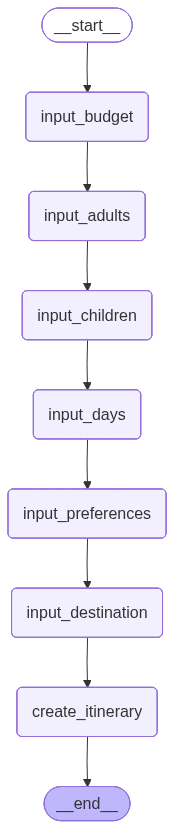

In [ ]:
display(
    Image(
        app.get_graph().draw_mermaid_png(
            draw_method = MermaidDrawMethod.API
        )
    )
)

In [ ]:
from langchain_core.messages import HumanMessage

def travel_planner(user_request: str):

    print(f"Initial Request: {user_request}\n")

    state = {
        "messages": [
            HumanMessage(content=user_request)
        ],

        # Required Inputs
        "budget": None,
        "adults": None,
        "children": None,
        "days": None,
        "preferences": [],
        "destination": None,

        # Optional Inputs
        "hotel_type": None,
        "food_preferences": [],
        "mobility_constraints": None,
        "must_visit_places": [],

        # Validation
        "input_valid": False,

        # Budget
        "budget_status": None,
        "cost_breakdown": {},

        # Recommendations
        "hotels": [],
        "restaurants": [],
        "attractions": [],
        "suggested_destinations": [],

        # Flags
        "trip_too_short": False,
        "regenerate": False,

        # Final Output
        "itinerary": ""
    }

    final_output = None

    for output in app.stream(state):
        final_output = output

    return final_output



In [31]:
result = travel_planner(
    """
    Budget: 80000 INR
    Adults: 2
    Children: 1
    Days: 5

    Preferences:
    Nature, Adventure, Family Friendly

    Destination: Munnar
    """
)

print(result



      )

Initial Request: 
    Budget: 80000 INR
    Adults: 2
    Children: 1
    Days: 5

    Preferences:
    Nature, Adventure, Family Friendly

    Destination: Munnar
    

Enter your total trip budget (INR):
Your Input: 10000
Enter the number of adults:
Your Input: 1
Enter the number of children:
Your Input: 0
Enter the number of travel days:
Your Input: 1
Enter sightseeing preferences (Nature, Beaches, Temples, Adventure, Shopping, Heritage):
Your Input: Thiruvalla
Enter destination (optional, press Enter for recommendations):
Your Input: Thiruvalla

Generating travel itinerary...


===== FINAL ITINERARY =====

**Thiruvalla Travel Itinerary**

**Destination Overview**
Thiruvalla is a charming town in the Pathanamthitta district of Kerala, India. It is known for its rich cultural heritage, historic temples, and natural beauty. The town matches your sightseeing preferences as it offers a unique blend of traditional and modern attractions.

**Day 1: Explore Thiruvalla**

* **Morning (9:00 